# Exploratory Data Analysis

This notebook explores the cleaned YouTube comment dataset to identify patterns in comment characteristics, audience engagement, and differences across the three content domains.

The analysis focuses on:
- dataset composition
- comment length
- audience engagement
- differences across domains
- differences across individual videos
- common words and text patterns

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
input_path = Path("../data/processed/youtube_comments_clean.csv")

df = pd.read_csv(input_path)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (750, 11)


,domain,creator,video_id,video_title,comment_id,comment_text,like_count,published_at,clean_text,character_count,word_count
0,technology,Mrwhosetheboss,PjAyUhf52D0,iPhone 18 Pro Review - My Last iPhone?,UgzKqfHI8Eags5rqHVJ4AaABAg,Learned a lot of lessons from the last time I ...,4919,2026-09-18T15:56:48Z,Learned a lot of lessons from the last time I ...,108,22
1,technology,Mrwhosetheboss,PjAyUhf52D0,iPhone 18 Pro Review - My Last iPhone?,Ugw2CZt8wqvMWpkUvml4AaABAg,18 pro series reporting lot of problems 😂pink ...,0,2026-09-26T17:23:15Z,18 pro series reporting lot of problems 😂pink ...,75,12
2,technology,Mrwhosetheboss,PjAyUhf52D0,iPhone 18 Pro Review - My Last iPhone?,UgxUGyHsxYZkzk7qHuF4AaABAg,What game is that??? 3:16,0,2026-09-26T16:45:06Z,What game is that??? 3:16,25,5
3,technology,Mrwhosetheboss,PjAyUhf52D0,iPhone 18 Pro Review - My Last iPhone?,UgyQxd36wlTmY5jj9_F4AaABAg,It's so cherry picking and most of the points ...,0,2026-09-26T16:19:00Z,It's so cherry picking and most of the points ...,841,150
4,technology,Mrwhosetheboss,PjAyUhf52D0,iPhone 18 Pro Review - My Last iPhone?,Ugwh_zxyYLUROYEJKwF4AaABAg,"You’ve never had thermal issues?? Holy cow, I’...",0,2026-09-26T15:12:19Z,"You’ve never had thermal issues?? Holy cow, I’...",124,22


## Dataset Composition

The dataset contains comments from three content domains: technology, travel, and cats.

The pilot dataset was designed to contain an equal number of comments from each domain, with 250 comments collected from five videos per creator.

In [3]:
domain_counts = df["domain"].value_counts()

print(domain_counts)

domain
technology    250
travel        250
cats          250
Name: count, dtype: int64


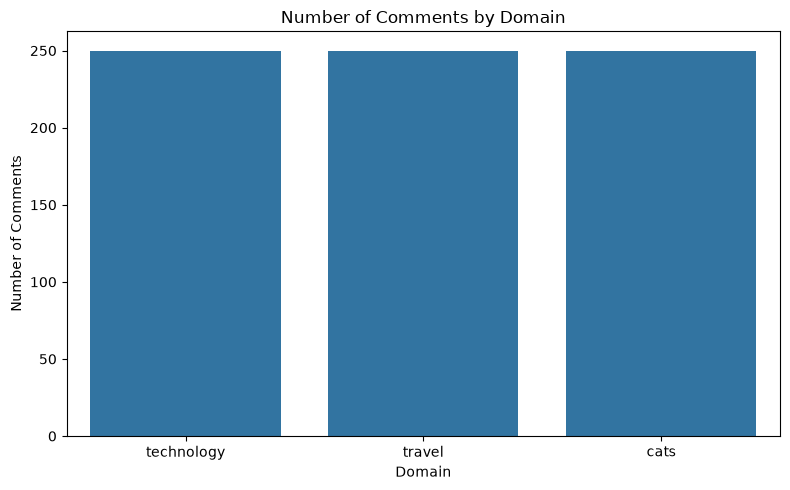

In [4]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="domain",
    order=domain_counts.index
)

plt.title("Number of Comments by Domain")
plt.xlabel("Domain")
plt.ylabel("Number of Comments")
plt.tight_layout()
plt.show()

## Comments per Video

The comments were sampled evenly across the selected videos.

Checking the distribution at the video level helps confirm that no individual video contributes disproportionately more comments to a domain.

In [5]:
video_counts = (
    df.groupby(["domain", "video_id"])
      .size()
      .reset_index(name="comment_count")
)

video_counts

,domain,video_id,comment_count
0,cats,D1sPbbd0Y14,50
1,cats,SrqMV7uSg1c,50
2,cats,_fC1khz15OA,50
3,cats,eVp8utdVS30,50
4,cats,hVhi6uL-l00,50
5,technology,DNRYkBMaf3Y,50
6,technology,Eo5w2S-h5dI,50
7,technology,PjAyUhf52D0,50
8,technology,VTLnDqjfRZQ,50
9,technology,n3F996g8wjg,50


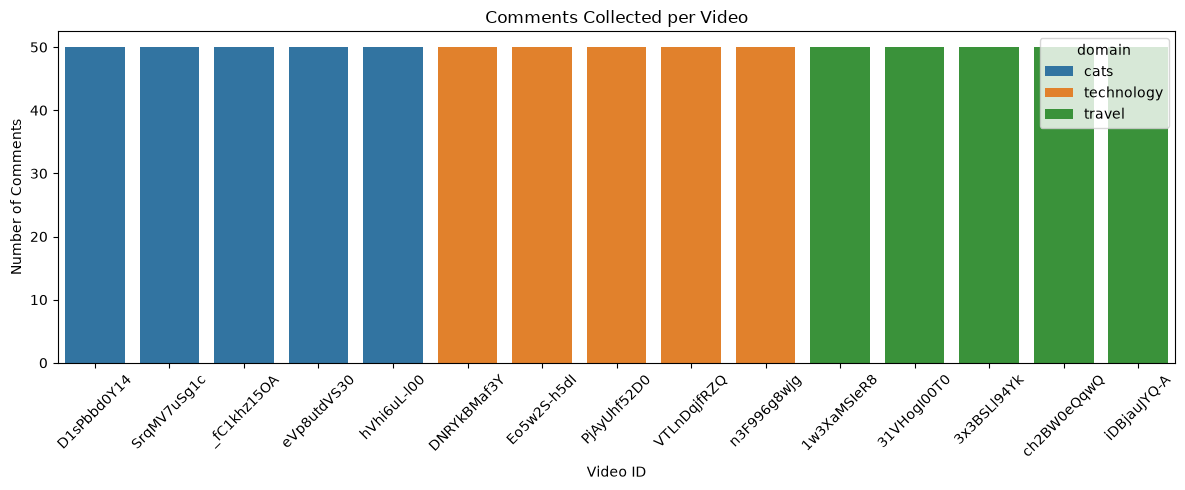

In [6]:
plt.figure(figsize=(12, 5))

sns.barplot(
    data=video_counts,
    x="video_id",
    y="comment_count",
    hue="domain"
)

plt.title("Comments Collected per Video")
plt.xlabel("Video ID")
plt.ylabel("Number of Comments")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Comment Length

Comment length provides a basic view of how audiences interact with the videos.

We examine both word count and character count to understand the typical length of comments and whether comment length differs across domains.

In [7]:
length_summary = df[["word_count", "character_count"]].describe()

length_summary

,word_count,character_count
count,750.000000,750.000000
mean,18.568000,97.081333
std,29.216517,156.537851
min,1.000000,1.000000
25%,5.000000,27.250000
50%,10.000000,51.000000
75%,22.000000,114.000000
max,466.000000,2492.000000


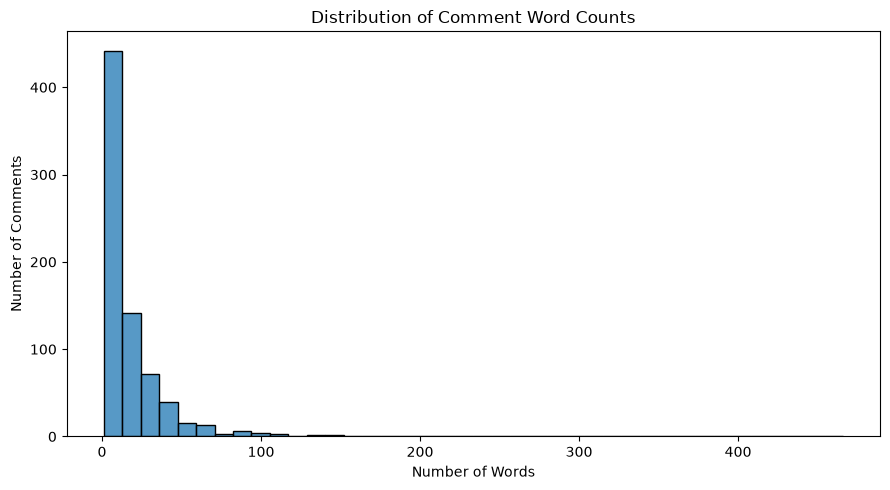

In [8]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="word_count",
    bins=40
)

plt.title("Distribution of Comment Word Counts")
plt.xlabel("Number of Words")
plt.ylabel("Number of Comments")
plt.tight_layout()
plt.show()

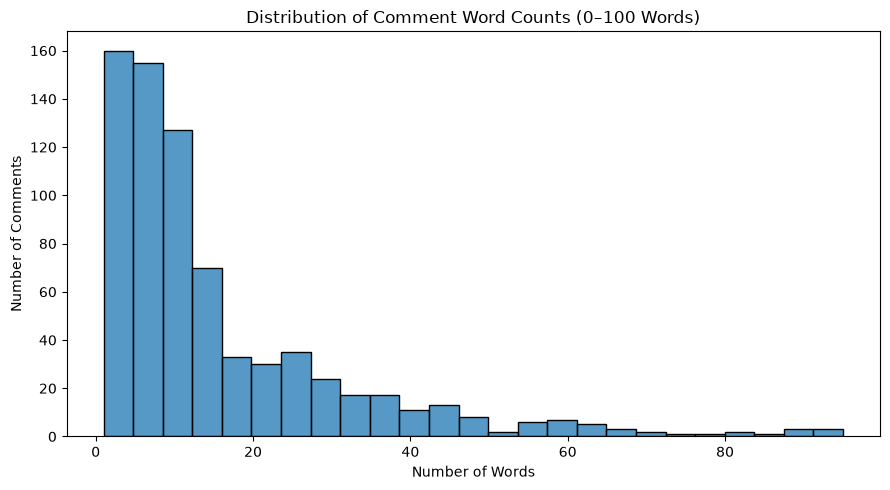

In [9]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df[df["word_count"] <= 100],
    x="word_count",
    bins=25
)

plt.title("Distribution of Comment Word Counts (0–100 Words)")
plt.xlabel("Number of Words")
plt.ylabel("Number of Comments")
plt.tight_layout()
plt.show()

## Comment Length by Domain

Comment length may vary across content domains because audiences may interact differently with different types of videos.

We compare the distribution of comment word counts across technology, travel, and cats.

In [10]:
domain_length = (
    df.groupby("domain")["word_count"]
      .agg(["count", "mean", "median", "std", "min", "max"])
      .round(2)
)

domain_length

,count,mean,median,std,min,max
domain,,,,,,
cats,250,25.10,16.0,29.83,1,267
technology,250,21.45,11.0,37.64,1,466
travel,250,9.15,7.0,10.98,1,95


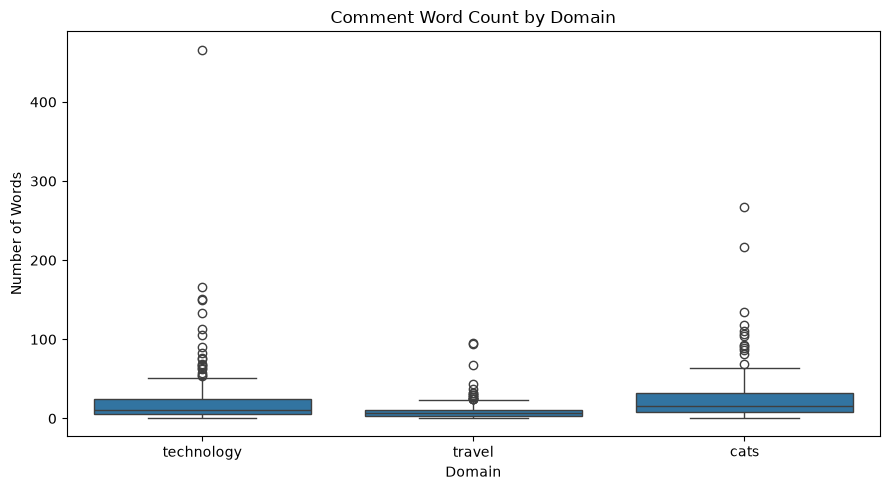

In [11]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="domain",
    y="word_count"
)

plt.title("Comment Word Count by Domain")
plt.xlabel("Domain")
plt.ylabel("Number of Words")

plt.tight_layout()
plt.show()

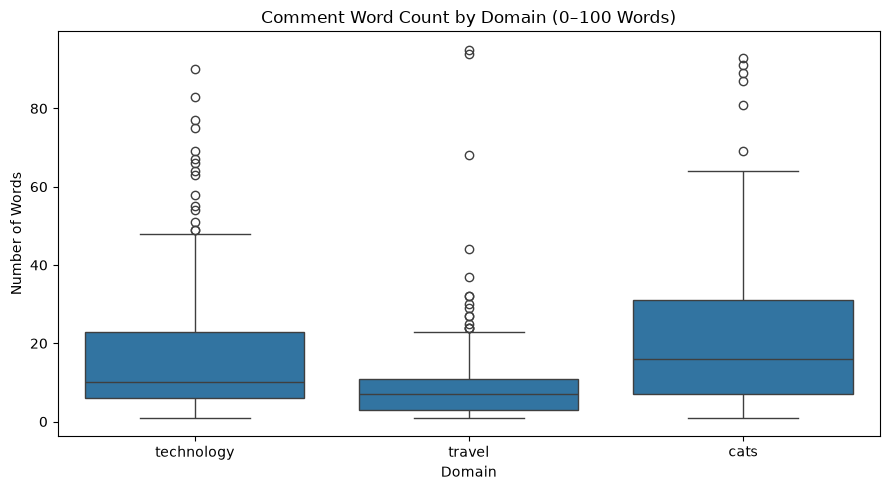

In [12]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df[df["word_count"] <= 100],
    x="domain",
    y="word_count"
)

plt.title("Comment Word Count by Domain (0–100 Words)")
plt.xlabel("Domain")
plt.ylabel("Number of Words")

plt.tight_layout()
plt.show()

## Audience Engagement

The `like_count` variable measures the number of likes received by each sampled comment.

Because YouTube comment likes are highly skewed, both summary statistics and a transformed visualization are used to examine the distribution.

In [13]:
df["like_count"].describe()

count     750.000000
mean       12.940000
std       218.038024
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max      4919.000000
Name: like_count, dtype: float64

In [14]:
zero_likes = (df["like_count"] == 0).sum()
zero_likes_pct = zero_likes / len(df) * 100

print("Comments with zero likes:", zero_likes)
print(f"Percentage with zero likes: {zero_likes_pct:.2f}%")

Comments with zero likes: 673
Percentage with zero likes: 89.73%


In [15]:
engagement_summary = (
    df.groupby("domain")["like_count"]
      .agg(["count", "mean", "median", "max"])
      .round(2)
)

engagement_summary

,count,mean,median,max
domain,,,,
cats,250,0.34,0.0,36
technology,250,31.63,0.0,4919
travel,250,6.86,0.0,1636


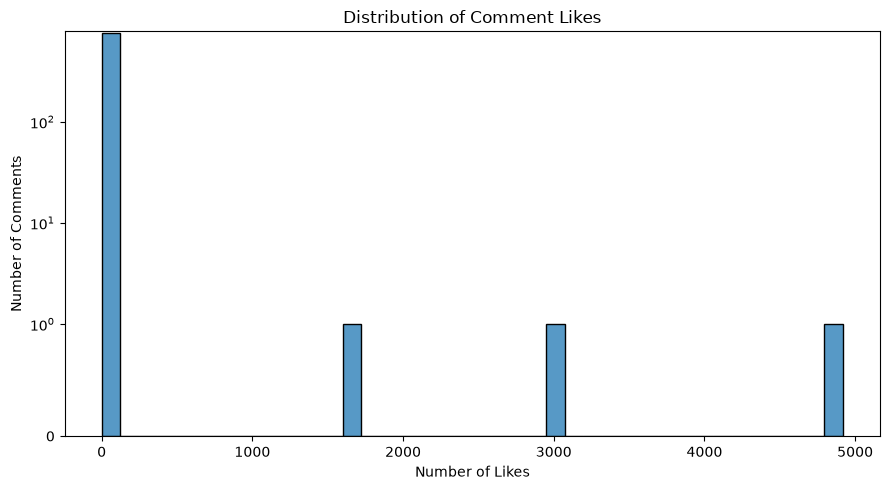

In [16]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="like_count",
    bins=40
)

plt.yscale("symlog", linthresh=1)

plt.title("Distribution of Comment Likes")
plt.xlabel("Number of Likes")
plt.ylabel("Number of Comments")

plt.tight_layout()
plt.show()

In [17]:
df["log_like_count"] = np.log1p(df["like_count"])

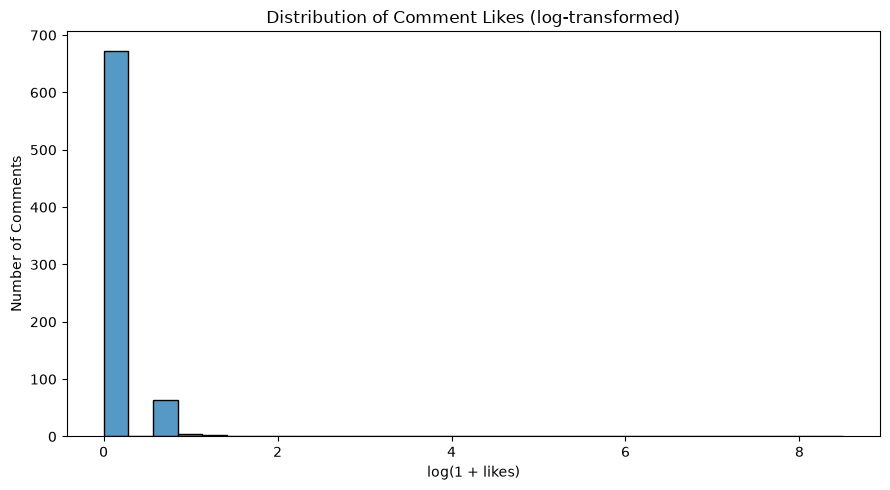

In [18]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="log_like_count",
    bins=30
)

plt.title("Distribution of Comment Likes (log-transformed)")
plt.xlabel("log(1 + likes)")
plt.ylabel("Number of Comments")

plt.tight_layout()
plt.show()

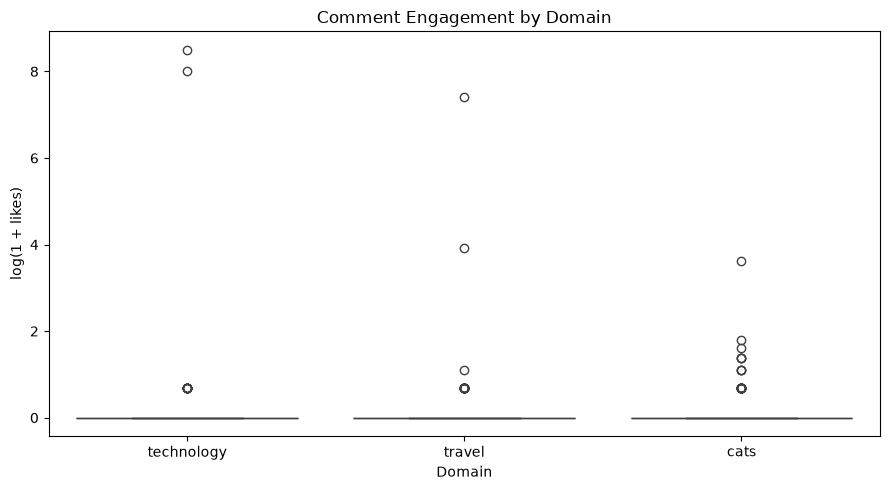

In [19]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="domain",
    y="log_like_count"
)

plt.title("Comment Engagement by Domain")
plt.xlabel("Domain")
plt.ylabel("log(1 + likes)")

plt.tight_layout()
plt.show()

## Comment Length and Audience Engagement

This section examines whether longer comments tend to receive more likes.

Because both comment length and engagement are strongly skewed, Spearman rank correlation is used to measure the strength of their monotonic association.

In [20]:
spearman_corr = df["word_count"].corr(
    df["like_count"],
    method="spearman"
)

print(f"Spearman correlation: {spearman_corr:.3f}")

Spearman correlation: 0.031


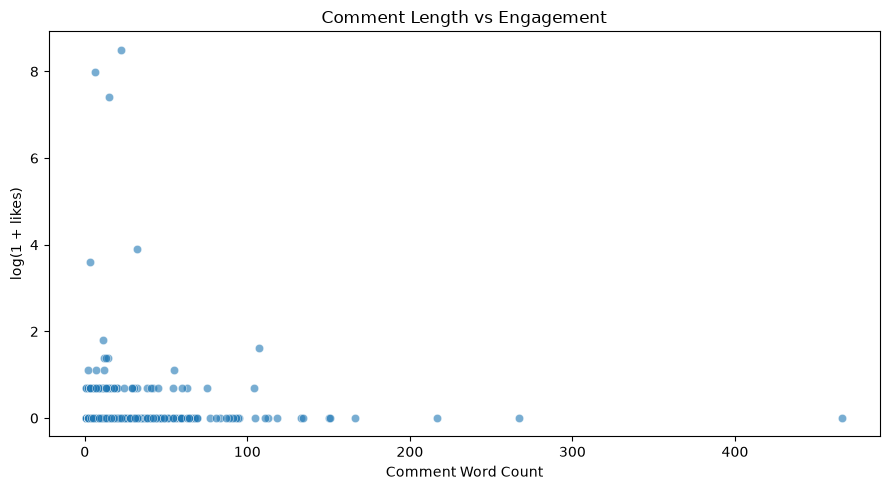

In [21]:
plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df,
    x="word_count",
    y="log_like_count",
    alpha=0.6
)

plt.title("Comment Length vs Engagement")
plt.xlabel("Comment Word Count")
plt.ylabel("log(1 + likes)")

plt.tight_layout()
plt.show()

## Comment Length and Engagement by Domain

The overall relationship between comment length and engagement may differ across content domains.

Spearman correlation is calculated separately for technology, travel, and cats to examine whether the association is consistent across the three groups.

In [22]:
domain_correlations = (
    df.groupby("domain")
      .apply(
          lambda group: group["word_count"].corr(
              group["like_count"],
              method="spearman"
          ),
          include_groups=False
      )
      .round(3)
)

domain_correlations

domain
cats         -0.078
technology    0.027
travel        0.193
dtype: float64

### Observation

Comment length showed little association with engagement in the sampled data. The overall Spearman correlation was 0.031, indicating an almost negligible monotonic relationship.

When examined separately by domain, technology (ρ = 0.027) and cats (ρ = -0.078) also showed very weak associations. Travel showed a somewhat larger positive association (ρ = 0.193), but this remains a weak relationship.

These results should be interpreted cautiously because comment likes are highly zero-inflated and strongly skewed.

## Common Words

The comment text is examined to identify frequently occurring words and common vocabulary within the dataset.

Stopwords are removed for this analysis so that common grammatical words do not dominate the results. The original comment text remains unchanged.

In [23]:
import nltk
from nltk.corpus import stopwords

In [24]:
nltk.download("stopwords")

/home/sandra/youtube-content-sentiment-analysis/.venv/lib/python3.14/site-packages/nltk/downloader.py:1076: UserWarning: NLTK will not authorize the non-private download directory '/home/sandra/nltk_data': it (or an ancestor) is world- or group-writable, so another local user could plant files there. Choose a private location such as ~/nltk_data.
  for msg in self.incr_download(info_or_id, download_dir, force):
[nltk_data] Downloading package stopwords to /home/sandra/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [25]:
stop_words = set(stopwords.words("english"))

In [26]:
from collections import Counter

words = (
    df["clean_text"]
    .str.lower()
    .str.findall(r"\b[a-zA-Z]{2,}\b")
    .explode()
)

words = words[~words.isin(stop_words)]

word_counts = Counter(words.dropna())

word_counts.most_common(20)

[('cat', 96),
 ('like', 73),
 ('treat', 58),
 ('one', 52),
 ('get', 50),
 ('cats', 49),
 ('button', 47),
 ('phone', 46),
 ('love', 45),
 ('video', 41),
 ('think', 38),
 ('would', 38),
 ('ryan', 36),
 ('go', 32),
 ('got', 29),
 ('never', 28),
 ('kurt', 28),
 ('need', 27),
 ('iphone', 26),
 ('could', 26)]

## Common Words by Domain

Overall word frequencies can be dominated by the vocabulary of one domain.

To identify domain-specific patterns, the most frequent words are therefore examined separately for technology, travel, and cats.

In [27]:
def get_common_words(text_series, n=15):
    words = (
        text_series
        .str.lower()
        .str.findall(r"\b[a-zA-Z]{2,}\b")
        .explode()
    )

    words = words[~words.isin(stop_words)]

    return Counter(words.dropna()).most_common(n)

In [28]:
for domain in df["domain"].unique():
    print(f"\n{domain.upper()}")
    print(get_common_words(
        df.loc[df["domain"] == domain, "clean_text"],
        n=15
    ))


TECHNOLOGY
[('phone', 44), ('iphone', 26), ('gaming', 21), ('one', 19), ('apple', 18), ('like', 18), ('get', 16), ('people', 15), ('use', 15), ('time', 13), ('camera', 13), ('need', 13), ('still', 13), ('games', 13), ('never', 12)]

TRAVEL
[('ryan', 36), ('like', 21), ('love', 15), ('videos', 12), ('video', 11), ('bro', 11), ('stefan', 10), ('go', 10), ('joyride', 10), ('one', 8), ('get', 8), ('really', 8), ('dad', 8), ('great', 7), ('back', 7)]

CATS
[('cat', 96), ('treat', 58), ('cats', 49), ('button', 47), ('like', 34), ('kurt', 28), ('get', 26), ('one', 25), ('think', 24), ('would', 22), ('gary', 22), ('put', 20), ('video', 19), ('buttons', 19), ('love', 18)]


## Domain-Specific Vocabulary Using TF-IDF

Word frequency alone does not show whether a word is distinctive to a particular domain.

TF-IDF is used to identify words that are relatively important within one domain while being less common across the other domains.

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [30]:
domain_text = (
    df.groupby("domain")["clean_text"]
      .apply(" ".join)
)

domain_text

domain
cats          Oh---! So, Couch-Sphinxes DO exist after all! ...
technology    Learned a lot of lessons from the last time I ...
travel        Hidden message of the video. It ALL ends with ...
Name: clean_text, dtype: str

In [31]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    token_pattern=r"(?u)\b[a-zA-Z]{2,}\b",
    max_df=0.67
)

tfidf_matrix = vectorizer.fit_transform(domain_text)

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    index=domain_text.index,
    columns=vectorizer.get_feature_names_out()
)

tfidf_df.shape

(3, 2419)

In [32]:
for domain in tfidf_df.index:
    print(f"\n{domain.upper()}")
    
    top_words = (
        tfidf_df.loc[domain]
        .sort_values(ascending=False)
        .head(15)
    )
    
    print(top_words)


CATS
cat        0.627273
treat      0.378977
cats       0.320170
button     0.307102
kurt       0.182955
gary       0.143750
buttons    0.124148
treats     0.091477
press      0.084943
loves      0.074540
couch      0.071875
know       0.069571
loved      0.065341
little     0.065341
toy        0.065341
Name: cats, dtype: float64

TECHNOLOGY
phone        0.411829
iphone       0.319981
apple        0.221525
gaming       0.196555
games        0.159990
ai           0.147684
time         0.121677
camera       0.121677
data         0.110763
companies    0.110763
samsung      0.110763
battery      0.102957
price        0.098456
tech         0.098456
literally    0.093598
Name: technology, dtype: float64

TRAVEL
ryan               0.718186
joyride            0.199496
stefan             0.199496
train              0.106205
canyon             0.099748
dantic             0.099748
north              0.079798
haley              0.079798
rununtiltheyrun    0.079798
journey            0.079798
gran

In [33]:
from nltk.stem import WordNetLemmatizer

In [34]:
nltk.download("wordnet")
nltk.download("omw-1.4")

/home/sandra/youtube-content-sentiment-analysis/.venv/lib/python3.14/site-packages/nltk/downloader.py:1076: UserWarning: NLTK will not authorize the non-private download directory '/home/sandra/nltk_data': it (or an ancestor) is world- or group-writable, so another local user could plant files there. Choose a private location such as ~/nltk_data.
  for msg in self.incr_download(info_or_id, download_dir, force):
[nltk_data] Downloading package wordnet to /home/sandra/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/sandra/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [35]:
lemmatizer = WordNetLemmatizer()

In [36]:
def lemmatize_text(text):
    words = re.findall(r"\b[a-zA-Z]{2,}\b", text.lower())
    words = [word for word in words if word not in stop_words]
    words = [lemmatizer.lemmatize(word) for word in words]
    return " ".join(words)

In [37]:
domain_text_lemma = (
    df.groupby("domain")["clean_text"]
      .apply(lambda x: " ".join(x))
      .apply(lemmatize_text)
)

domain_text_lemma

domain
cats          oh couch sphinx exist ancient egyptian whoever...
technology    learned lot lesson last time dual personality ...
travel        hidden message video end jesus sweden yeaaaa d...
Name: clean_text, dtype: str

In [38]:
vectorizer = TfidfVectorizer(
    max_df=0.67,
    token_pattern=r"(?u)\b[a-zA-Z]{2,}\b"
)

tfidf_matrix = vectorizer.fit_transform(domain_text_lemma)

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    index=domain_text_lemma.index,
    columns=vectorizer.get_feature_names_out()
)

In [39]:
print("TF-IDF matrix shape:", tfidf_matrix.shape)
print("TF-IDF dataframe shape:", tfidf_df.shape)

TF-IDF matrix shape: (3, 2307)
TF-IDF dataframe shape: (3, 2307)


In [40]:
for domain in tfidf_df.index:
    print(f"\n{domain.upper()}")

    top_words = (
        tfidf_df.loc[domain]
        .sort_values(ascending=False)
        .head(15)
    )

    print(top_words)


CATS
cat         0.757257
treat       0.376017
button      0.344682
kurt        0.146229
gary        0.114894
toy         0.067892
press       0.067892
couch       0.057447
know        0.055605
little      0.052225
loved       0.052225
cute        0.051634
time        0.051634
water       0.047662
stroller    0.047662
Name: cats, dtype: float64

TECHNOLOGY
phone      0.448297
iphone     0.300507
apple      0.208044
gaming     0.184593
year       0.149432
company    0.140642
ai         0.138696
time       0.131852
price      0.127138
camera     0.123062
know       0.114272
tech       0.104022
data       0.104022
samsung    0.104022
battery    0.096691
Name: technology, dtype: float64

TRAVEL
ryan               0.719367
stefan             0.199824
joyride            0.199824
train              0.106380
country            0.106380
canyon             0.099912
dantic             0.099912
grand              0.079930
haley              0.079930
journey            0.079930
rununtiltheyrun    

## Distinctive Vocabulary by Domain

The highest TF-IDF terms provide a view of vocabulary that is particularly characteristic of each domain in the sampled comments.

The terms reflect both domain topics and specific people, products, and events mentioned in the selected videos.

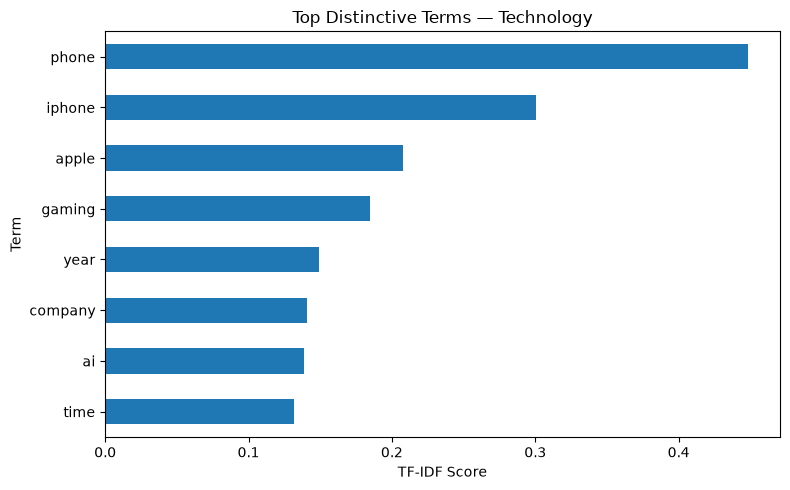

In [41]:
top_tech = tfidf_df.loc["technology"].sort_values(ascending=False).head(8)

plt.figure(figsize=(8, 5))

top_tech.sort_values().plot(kind="barh")

plt.title("Top Distinctive Terms — Technology")
plt.xlabel("TF-IDF Score")
plt.ylabel("Term")
plt.tight_layout()
plt.show()

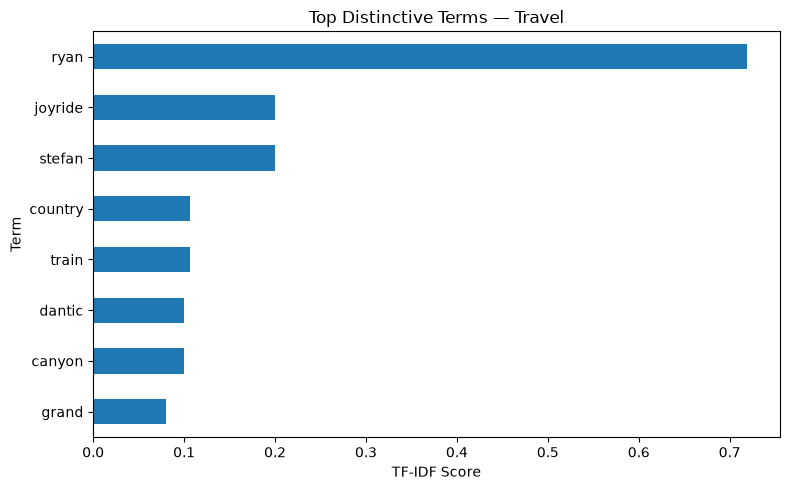

In [42]:
top_travel = tfidf_df.loc["travel"].sort_values(ascending=False).head(8)

plt.figure(figsize=(8, 5))

top_travel.sort_values().plot(kind="barh")

plt.title("Top Distinctive Terms — Travel")
plt.xlabel("TF-IDF Score")
plt.ylabel("Term")
plt.tight_layout()
plt.show()

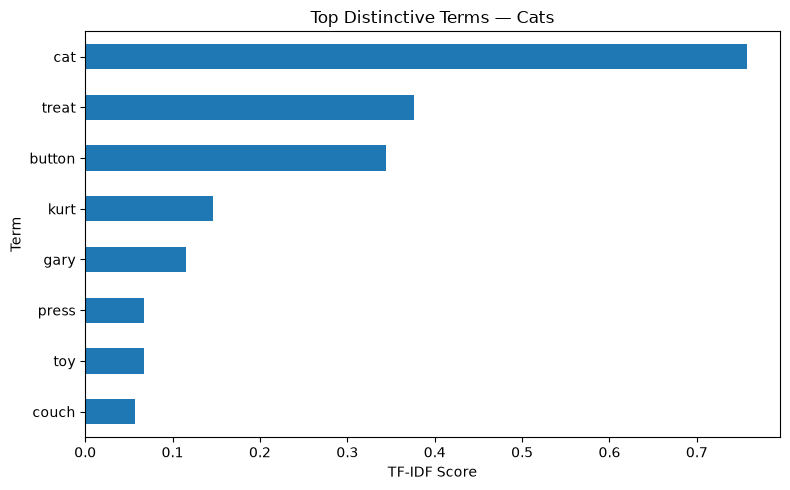

In [43]:
top_cats = tfidf_df.loc["cats"].sort_values(ascending=False).head(8)

plt.figure(figsize=(8, 5))

top_cats.sort_values().plot(kind="barh")

plt.title("Top Distinctive Terms — Cats")
plt.xlabel("TF-IDF Score")
plt.ylabel("Term")
plt.tight_layout()
plt.show()

In [44]:
df[
    df["clean_text"].str.contains("dantic", case=False, na=False)
][["domain", "video_title", "clean_text"]]

,domain,video_title,clean_text
256,travel,How Many Countries Can I Visit in 7 Days?,Bro that's literally dantic
261,travel,How Many Countries Can I Visit in 7 Days?,Dantic is not a stranger
280,travel,How Many Countries Can I Visit in 7 Days?,Dantic is that you???
293,travel,How Many Countries Can I Visit in 7 Days?,Did no one notice he met dantic
295,travel,How Many Countries Can I Visit in 7 Days?,Dantic??


## EDA Summary

The exploratory analysis identified several characteristics of the sampled YouTube comments:

- The dataset is evenly distributed across the three domains, with 250 comments per domain.
- Most comments are short, with a median length of 10 words, while a small number of substantially longer comments create a strong right-skew.
- Comment length differs across the sampled domains, with travel comments having the lowest median length and cat comments having the highest.
- Comment engagement is highly skewed: 89.73% of sampled comments received zero likes.
- Comment length showed almost no overall monotonic association with engagement (Spearman ρ = 0.031).
- Domain-specific vocabulary reflects the topics, products, people, and events present in the selected videos. TF-IDF highlights terms such as phones and gaming in technology, travel-related terms and creator references in travel, and cats, treats, and buttons in the cat videos.

These findings provide context for the next stage of the project: sentiment analysis.